# Data Processing

Data preprocessing is a crucial first step in any machine learning project. It involves **cleaning, transforming, and preparing data** so that models can learn effectively. In this notebook, you will explore common preprocessing techniques and apply them with practical examples, building a strong foundation for future modeling tasks.

## 1️⃣ Handling Missing Values

Missing data is a common problem in real-world datasets. It can occur due to:

*   Human error during data entry
*   Sensor or system failures during data collection
*   Incomplete surveys or forms


Why Missing Values Matter

*  Many machine learning algorithms cannot handle missing data directly
*  Ignoring or mishandling missing values can bias results or reduce model performance


Common Strategies to Handle Missing Values

1. Remove rows

  *  Drop rows that contain missing values
  *  Best when missing values are few and random


2. Remove columns

  *  Drop columns with a large proportion of missing values
  *  Useful when the column is mostly empty or not important

3. Imputation (mean/median/mode)

  *  Replace missing values with the mean, median, or mode of the column
  *  Common for numeric or categorical features with few missing entries

4. Leave as is
  *  Some algorithms (like XGBoost) can handle missing values natively
  *  Only in rare cases or for specific models

Key Takeaway: Handling missing values appropriately is essential for building reliable machine learning models. Even simple strategies like removing rows or filling with mean/median can significantly improve model performance.

In [1]:
import pandas as pd
import numpy as np

# Sample dataset
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David', np.nan],
    'Age': [25, np.nan, 30, 22, 28],
    'Salary': [50000, 54000, np.nan, 58000, 60000],
    'Department': ['HR', 'IT', 'IT', np.nan, 'Finance']
}

df = pd.DataFrame(data)
print("Original DataFrame:")
print(df)


Original DataFrame:
      Name   Age   Salary Department
0    Alice  25.0  50000.0         HR
1      Bob   NaN  54000.0         IT
2  Charlie  30.0      NaN         IT
3    David  22.0  58000.0        NaN
4      NaN  28.0  60000.0    Finance


In [2]:
# 1. Drop rows with missing values

df_dropped = df.dropna()
print("After dropping rows with missing values:")
print(df_dropped)


After dropping rows with missing values:
    Name   Age   Salary Department
0  Alice  25.0  50000.0         HR


In [3]:
# Fill numeric columns with mean
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Salary'] = df['Salary'].fillna(df['Salary'].median())

# Fill categorical column with mode
df['Department'] = df['Department'].fillna(df['Department'].mode()[0])

print("After filling missing values:")
print(df)

After filling missing values:
      Name    Age   Salary Department
0    Alice  25.00  50000.0         HR
1      Bob  26.25  54000.0         IT
2  Charlie  30.00  56000.0         IT
3    David  22.00  58000.0         IT
4      NaN  28.00  60000.0    Finance


## 2️⃣ Structured vs Unstructured Data

Data in machine learning can generally be divided into two types:

1. Structured Data

  *  Organized in a tabular format (rows and columns)

  *  Each column represents a feature, each row represents a record

  *  Easy to analyze and preprocess using standard tools like pandas

  *  Examples: CSV files, spreadsheets, relational databases

2. Unstructured Data

  *  Does not follow a predefined format

  *  Can include text, images, audio, video, or social media posts

  *  Requires special preprocessing techniques (e.g., NLP for text, computer vision for images)

  *  Examples: Tweets, images from cameras, audio recordings, PDF documents


Understanding the type of data is crucial because it determines how you preprocess it and which machine learning techniques are appropriate.

In [4]:
import pandas as pd
import numpy as np

# Example of structured data
structured_data = {
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Age': [25, 30, 22],
    'Salary': [50000, 60000, 55000]
}
df_structured = pd.DataFrame(structured_data)
print("Structured Data:")
print(df_structured)

# Example of unstructured data (list of text documents)
unstructured_data = [
    "Machine learning is fascinating.",
    "Data preprocessing is crucial.",
    "Python is widely used in data science."
]
print("\nUnstructured Data (Text):")
for i, text in enumerate(unstructured_data, 1):
    print(f"{i}: {text}")


Structured Data:
      Name  Age  Salary
0    Alice   25   50000
1      Bob   30   60000
2  Charlie   22   55000

Unstructured Data (Text):
1: Machine learning is fascinating.
2: Data preprocessing is crucial.
3: Python is widely used in data science.


## 3️⃣ Feature Scaling

Feature scaling is an important preprocessing step in machine learning. It ensures that all features contribute equally to the model by bringing them to a similar scale. This is especially important for algorithms that rely on distance measures (e.g., KNN, SVM) or gradient-based optimization (e.g., linear regression, neural networks).

Common methods of feature scaling:

1. Normalization (Min-Max Scaling)

Scales features to a fixed range, usually [0, 1]

Formula:

$$X_{\text{scaled}} = \frac{X - X_{\min}}{X_{\max} - X_{\min}}$$


Useful when you want all features in the same range

2. Standardization (Z-score Scaling)

Centers the feature around 0 and scales to unit variance

Formula:

$$X_{\text{scaled}} = \frac{X - \mu}{\sigma}$$


Useful when features have different units or distributions

Key Takeaway:
Scaling does not change the shape of the data distribution (except for normalization which compresses it to a fixed range), but it helps algorithms converge faster and often improves model performance.

In [5]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd

# Sample dataset
data = {
    'Height': [150, 160, 170, 180, 190],
    'Weight': [50, 60, 65, 80, 90]
}
df = pd.DataFrame(data)
print("Original Data:")
print(df)

Original Data:
   Height  Weight
0     150      50
1     160      60
2     170      65
3     180      80
4     190      90


In [6]:
# Normalization (Min-Max Scaling)
scaler_norm = MinMaxScaler()
df_norm = pd.DataFrame(scaler_norm.fit_transform(df), columns=df.columns)
print("\nAfter Normalization:")
print(df_norm)


After Normalization:
   Height  Weight
0    0.00   0.000
1    0.25   0.250
2    0.50   0.375
3    0.75   0.750
4    1.00   1.000


In [7]:
# Standardization (Z-score Scaling)
scaler_std = StandardScaler()
df_std = pd.DataFrame(scaler_std.fit_transform(df), columns=df.columns)
print("\nAfter Standardization:")
print(df_std)


After Standardization:
     Height    Weight
0 -1.414214 -1.330266
1 -0.707107 -0.630126
2  0.000000 -0.280056
3  0.707107  0.770154
4  1.414214  1.470294


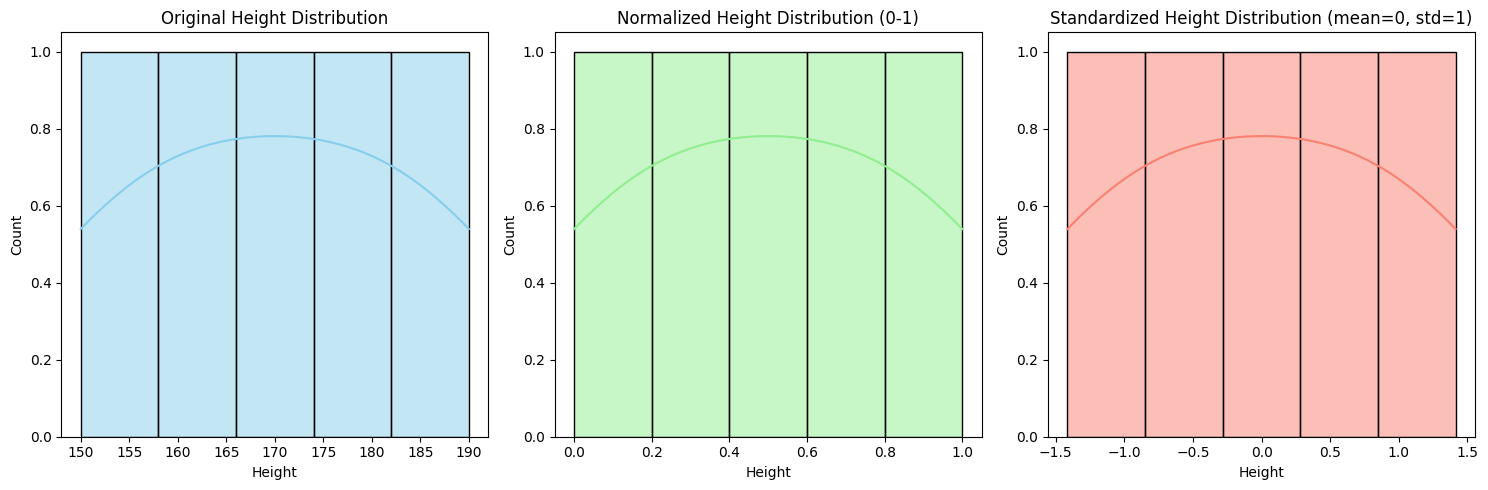

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Original data
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df['Height'], bins=5, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Original Height Distribution")

sns.histplot(df_norm['Height'], bins=5, kde=True, ax=axes[1], color="lightgreen")
axes[1].set_title("Normalized Height Distribution (0-1)")

sns.histplot(df_std['Height'], bins=5, kde=True, ax=axes[2], color="salmon")
axes[2].set_title("Standardized Height Distribution (mean=0, std=1)")

plt.tight_layout()
plt.show()


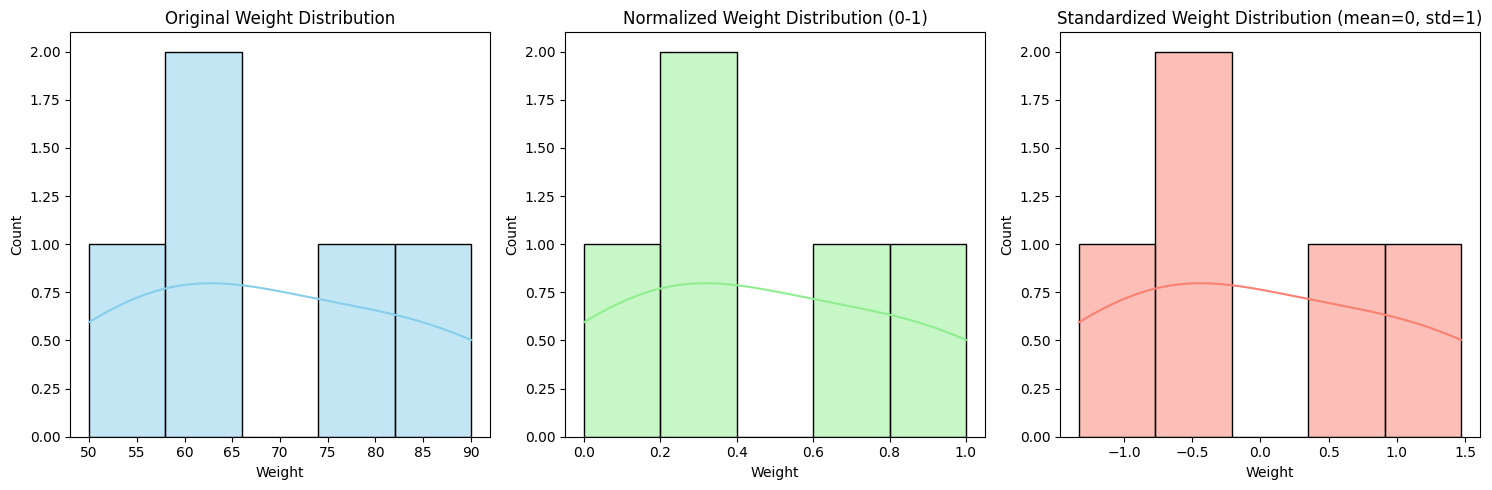

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Original data
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df['Weight'], bins=5, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Original Weight Distribution")

sns.histplot(df_norm['Weight'], bins=5, kde=True, ax=axes[1], color="lightgreen")
axes[1].set_title("Normalized Weight Distribution (0-1)")

sns.histplot(df_std['Weight'], bins=5, kde=True, ax=axes[2], color="salmon")
axes[2].set_title("Standardized Weight Distribution (mean=0, std=1)")

plt.tight_layout()
plt.show()


## 4️⃣ Encoding Categorical Variables

Machine learning algorithms typically require numerical input, so categorical variables must be converted into numeric form.

There are different types of categorical variables:

1. Nominal Variables

  *  Categories have no inherent order

  *  Examples: Color (Red, Blue, Green), Department (HR, IT, Finance)

2. Ordinal Variables

  *  Categories have a natural order

  *  Examples: Education Level (High School < Bachelor < Master < PhD), Customer Satisfaction (Low < Medium < High)

Common encoding techniques:

1. Label Encoding

Assigns a unique integer to each category

Suitable for ordinal variables where the order matters

2. One-Hot Encoding

Creates a new binary column for each category

Suitable for nominal variables

Prevents the model from assuming any ordinal relationship

Key Takeaway:
Encoding ensures categorical data can be used in models without introducing misleading relationships. Choosing the right encoding method depends on whether the categories have an inherent order.

In [10]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Sample dataset
data = {
    'Department': ['HR', 'IT', 'Finance', 'IT', 'HR'],
    'Education': ['Bachelor', 'Master', 'PhD', 'Bachelor', 'Master']
}
df = pd.DataFrame(data)
print("Original Data:")
print(df)

Original Data:
  Department Education
0         HR  Bachelor
1         IT    Master
2    Finance       PhD
3         IT  Bachelor
4         HR    Master


In [11]:
# Label Encoding (for ordinal or ordered features)
label_encoder = LabelEncoder()
df['Education_encoded'] = label_encoder.fit_transform(df['Education'])
print("\nAfter Label Encoding 'Education':")
print(df)


After Label Encoding 'Education':
  Department Education  Education_encoded
0         HR  Bachelor                  0
1         IT    Master                  1
2    Finance       PhD                  2
3         IT  Bachelor                  0
4         HR    Master                  1


In [12]:
# One-Hot Encoding (for nominal features)
df_onehot = pd.get_dummies(df, columns=['Department'])
print("\nAfter One-Hot Encoding 'Department':")
print(df_onehot)


After One-Hot Encoding 'Department':
  Education  Education_encoded  Department_Finance  Department_HR  \
0  Bachelor                  0               False           True   
1    Master                  1               False          False   
2       PhD                  2                True          False   
3  Bachelor                  0               False          False   
4    Master                  1               False           True   

   Department_IT  
0          False  
1           True  
2          False  
3           True  
4          False  


## 5️⃣ Outlier Detection and Handling

Outliers are data points that differ significantly from other observations. They can arise due to errors (e.g., incorrect data entry) or natural variation in the data.
$$$$

Why outliers matter:

* They can skew statistical measures like mean and standard deviation

* They may mislead models that are sensitive to extreme values (e.g., linear regression, KNN)

* In some cases, outliers may represent important rare events (e.g., fraud detection, equipment failure)

Common methods to detect outliers:

1. Visual methods

    * Histograms, boxplots, and scatter plots are simple ways to spot extreme values

2. Statistical methods

    * Z-score method: Values more than 3 standard deviations from the mean are potential outliers

    * IQR method:

        * Compute Interquartile Range $$IQR = Q3 − Q1$$

        * A data point is an outlier if it falls below:
        $$Q1 - 1.5 × IQR$$

        * or above:
        $$Q3 + 1.5 × IQR$$


3. Model-based methods

    * Isolation Forest
    * DBSCAN
    * Other clustering techniques

Handling outliers:

* Remove them if they are errors or irrelevant

* Transform them (e.g., log transformation)

* Cap them (winsorization) if they distort analysis

* Keep them if they are meaningful for the problem

Key Takeaway:

Outliers are not always “bad” — the right approach depends on whether they are noise or valuable signals.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sample dataset with an outlier
data = {
    'Height': [150, 160, 170, 180, 190, 300],  # 300 is an outlier
    'Weight': [50, 60, 65, 80, 90, 200]        # 200 is an outlier
}
df_outliers = pd.DataFrame(data)
print("Original Data:")
print(df_outliers)

Original Data:
   Height  Weight
0     150      50
1     160      60
2     170      65
3     180      80
4     190      90
5     300     200


Text(0.5, 1.0, 'Height Boxplot')

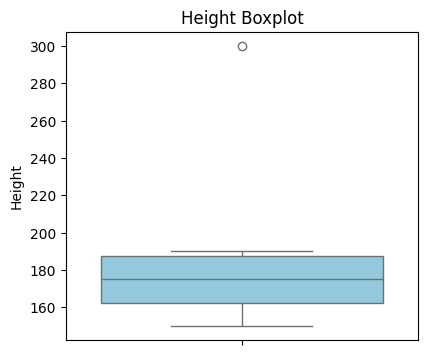

In [14]:
# Visualize with boxplots
plt.figure(figsize=(10,4))
plt.subplot(1, 2, 1)
sns.boxplot(y=df_outliers['Height'], color="skyblue")
plt.title("Height Boxplot")

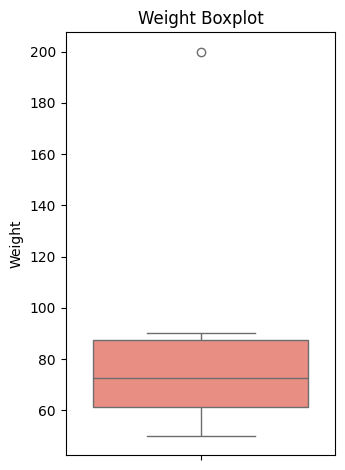

In [15]:
plt.subplot(1, 2, 2)
sns.boxplot(y=df_outliers['Weight'], color="salmon")
plt.title("Weight Boxplot")
plt.tight_layout()
plt.show()

In [16]:
# Detect outliers using IQR
Q1 = df_outliers['Height'].quantile(0.25)
Q3 = df_outliers['Height'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [17]:
outliers = df_outliers[(df_outliers['Height'] < lower_bound) | (df_outliers['Height'] > upper_bound)]
print("\nDetected outliers in 'Height':")
print(outliers)


Detected outliers in 'Height':
   Height  Weight
5     300     200


In [18]:
# Remove outliers
df_clean = df_outliers[(df_outliers['Height'] >= lower_bound) & (df_outliers['Height'] <= upper_bound)]
print("\nData after removing outliers:")
print(df_clean)


Data after removing outliers:
   Height  Weight
0     150      50
1     160      60
2     170      65
3     180      80
4     190      90


## 6️⃣ Feature Engineering vs. Feature Selection

Feature Engineering

* The process of creating new features from existing data to improve model performance

* Helps models capture hidden patterns and relationships

* Examples:

    * Extracting day, month, year from a date column

    * Creating BMI from height and weight

    * Combining text features (e.g., word counts, sentiment scores)

Feature Selection

* The process of choosing the most important features for training a model

* Helps reduce overfitting, improve training speed, and simplify models

* Methods:

  * Filter methods: Select features based on statistics (e.g., correlation, chi-square)

  * Wrapper methods: Use models to evaluate subsets of features (e.g., recursive feature elimination)

  * Embedded methods: Algorithms that select features automatically (e.g., Lasso regression, decision trees)

Key Difference:

* Feature Engineering = create new features

* Feature Selection = choose the most useful features

Key Takeaway:

Feature engineering expands the dataset with meaningful variables, while feature selection trims it down to only what really matters. Both improve model performance.

In [19]:
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_regression

# Sample dataset
data = {
    'Height': [150, 160, 170, 180, 190],
    'Weight': [50, 60, 65, 80, 90],
    'Age': [25, 30, 35, 40, 45],
    'Salary': [3000, 4000, 5000, 6000, 7000]  # Target variable
}
df = pd.DataFrame(data)
print("Original Data:")
print(df)

Original Data:
   Height  Weight  Age  Salary
0     150      50   25    3000
1     160      60   30    4000
2     170      65   35    5000
3     180      80   40    6000
4     190      90   45    7000


In [20]:
# --- Feature Engineering Example ---
# Create a new feature: BMI = Weight / (Height/100)^2
df['BMI'] = df['Weight'] / ((df['Height']/100) ** 2)
print("\nAfter Feature Engineering (added BMI):")
print(df)


After Feature Engineering (added BMI):
   Height  Weight  Age  Salary        BMI
0     150      50   25    3000  22.222222
1     160      60   30    4000  23.437500
2     170      65   35    5000  22.491349
3     180      80   40    6000  24.691358
4     190      90   45    7000  24.930748


In [21]:
# --- Feature Selection Example ---
X = df[['Height', 'Weight', 'Age', 'BMI']]
y = df['Salary']

selector = SelectKBest(score_func=f_regression, k=2)
X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]
print("\nSelected Features:")
print(selected_features)


Selected Features:
Index(['Height', 'Age'], dtype='object')


## 7️⃣ Train-Test Split & Data Leakage Prevention

Train-Test Split

* In machine learning, we need to evaluate model performance on unseen data.

* Splitting the dataset into training and testing sets helps us estimate how well the model generalizes.

* Common splits:

  * 70% train / 30% test

  * 80% train / 20% test

Data Leakage

* Occurs when information from the test set accidentally leaks into the training process

* Can cause overly optimistic performance and poor generalization

* Examples of data leakage:

  * Using future data to predict the past

  * Applying scaling or encoding before splitting

  * Including target information as a feature

Best Practices to Avoid Data Leakage:

* Always split the dataset first, then apply preprocessing (scaling, encoding) separately to training and test sets

* Use pipelines to automate preprocessing without leaking test information

* Be careful with time-series data — use chronological splits

Key Takeaway:

A proper train-test split is critical for reliable model evaluation, and preventing data leakage ensures your model generalizes well to new data.

In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Sample dataset
data = {
    'Height': [150, 160, 170, 180, 190],
    'Weight': [50, 60, 65, 80, 90],
    'Age': [25, 30, 35, 40, 45],
    'Salary': [3000, 4000, 5000, 6000, 7000]  # Target variable
}
df = pd.DataFrame(data)
print(df)

   Height  Weight  Age  Salary
0     150      50   25    3000
1     160      60   30    4000
2     170      65   35    5000
3     180      80   40    6000
4     190      90   45    7000


In [23]:

# Features and target
X = df[['Height', 'Weight', 'Age']]
y = df['Salary']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Training Features:")
print(X_train)
print("\nTesting Features:")
print(X_test)

Training Features:
   Height  Weight  Age
2     170      65   35
0     150      50   25
3     180      80   40

Testing Features:
   Height  Weight  Age
1     160      60   30
4     190      90   45


In [24]:
# Apply scaling only after splitting to avoid data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # only transform on test set

print("\nScaled Training Features:")
print(X_train_scaled)
print("\nScaled Testing Features:")
print(X_test_scaled)


Scaled Training Features:
[[ 0.26726124  0.          0.26726124]
 [-1.33630621 -1.22474487 -1.33630621]
 [ 1.06904497  1.22474487  1.06904497]]

Scaled Testing Features:
[[-0.53452248 -0.40824829 -0.53452248]
 [ 1.87082869  2.04124145  1.87082869]]


Key Points in the Code:

* The split happens before scaling

* fit_transform is applied only on training data

* transform is applied on test data, preventing leakage

## 8️⃣ Automated Tools & Pipelines

In machine learning projects, preprocessing often involves multiple steps like:

* Handling missing values

* Encoding categorical variables

* Scaling features

Manually applying these steps every time can be **time-consuming** and **error-prone**. This is where pipelines come in.

**What is a Pipeline?**

* A pipeline is a sequential chain of preprocessing steps and a model

* Ensures all transformations are applied consistently

* Helps prevent data leakage by applying transformations only on training data during fit and using the same transformations on test data

**About the Model Step (Linear Regression in this Example)**

* In this pipeline, we use Linear Regression as the model

* Linear Regression is a predictive algorithm that estimates a relationship between input features and a target variable

* We won’t go into full details here — that will be covered in the next lecture

**Advantages of Pipelines:**

* Automates repetitive tasks

* Makes code cleaner and easier to maintain

* Reduces risk of data leakage

* Facilitates grid search / hyperparameter tuning

Key Takeaway:

Using pipelines allows you to combine preprocessing and modeling into a single workflow, improving reproducibility and reducing mistakes.

In [25]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Sample dataset
data = {
    'Height': [150, 160, 170, 180, 190],
    'Weight': [50, 60, 65, 80, 90],
    'Department': ['HR', 'IT', 'Finance', 'IT', 'HR'],
    'Salary': [3000, 4000, 5000, 6000, 7000]  # Target
}
df = pd.DataFrame(data)
print(df)

   Height  Weight Department  Salary
0     150      50         HR    3000
1     160      60         IT    4000
2     170      65    Finance    5000
3     180      80         IT    6000
4     190      90         HR    7000


In [26]:
# Features and target
X = df[['Height', 'Weight', 'Department']]
y = df['Salary']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [27]:
# Preprocessing steps
numeric_features = ['Height', 'Weight']
numeric_transformer = StandardScaler()

categorical_features = ['Department']
categorical_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [28]:
# Pipeline with preprocessing + model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [29]:
# Train the model
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Height', 'Weight']),
                                                 ('cat', OneHotEncoder(),
                                                  ['Department'])])),
                ('regressor', LinearRegression())])

In [30]:
# Predict
y_pred = pipeline.predict(X_test)
print("Predictions:", y_pred)

Predictions: [4273.17073171 6453.65853659]


## Assignment

Use the Titanic dataset from [Kaggle](https://www.kaggle.com/c/titanic/data)

1️⃣ Explore the dataset

* Summarize numeric and categorical columns

* Identify missing values and unusual data types

* Visualize distributions for numeric features

2️⃣ Handle missing values

* Decide how to treat missing values for each column

* Justify your approach (mean, median, mode, drop, or another method)

* Compare the dataset before and after imputation

3️⃣ Detect and handle outliers

* Identify outliers in at least two numeric columns using any method(s) you choose

* Decide whether to remove, cap, or transform outliers, and justify your choice

* Visualize the results

4️⃣ Encode categorical variables

* Decide which columns are nominal vs. ordinal

* Apply appropriate encoding (One-Hot, Label, or another)

* Explain why you chose this method

5️⃣ Scale numeric features

* Apply scaling to at least two numeric columns

* Show before-and-after distributions and discuss how scaling affects the data

6️⃣ Feature engineering

* Create at least one new feature derived from existing data

* Explain why this feature could be informative for modeling

7️⃣ Feature selection / importance

* Analyze correlations or other relationships between features and the target

* Identify redundant or less informative features

* Explain your reasoning

8️⃣ Train-Test Split & Data Leakage Awareness

* Split the data into training and test sets

* Explain how you avoided data leakage

9️⃣ Pipeline

* Create a pipeline that combines at least three preprocessing steps

* Ensure it can be applied to new/unseen data without modifications